# Objective

The objective of this analysis is to identify products that are frequently purchased together within complementary categories, such as Pasta and Pasta Sauce.

By applying Market Basket Analysis, we aim to:

Discover strong associations between products
Understand customer purchasing behavior
Identify potential cross-selling opportunities

# Problem Statement

In retail datasets, it is often unclear which specific products within related categories are commonly bought together.

This raises key business questions:

Which products from complementary categories (e.g., Pasta & Pasta Sauce) are frequently co-purchased?
Are there strong associations between specific product pairs?
Can these relationships be leveraged for cross-promotional strategies?

Without answering these questions, businesses may miss opportunities to:

Increase average basket value
Design effective product bundles
Optimize in-store or online product placement

### dh_transactions

| Variable             | Description |
|----------------------|------------|
| upc                  | Standard 10-digit unique product code |
| dollar_sales         | Amount of dollars spent by the consumer |
| units                | Number of products purchased by the consumer |
| time_of_transaction  | The time of transaction expressed in military time |
| geography            | Distinguishes between two large geographical regions (values: 1 or 2) |
| week                 | Week of the transaction (values: 1–104, chronological order) |
| household            | Identifies unique households |
| store                | Identifies unique stores |
| basket               | Identifies unique baskets/trips to the store |
| day                  | Day of the transaction (1–728). |
| coupon               | Indicates coupon usage (1 = used, 0 = not used) |

### dh_product_lookup

| Variable            | Description |
|---------------------|------------|
| upc                 | Standard 10-digit unique product code |
| product_description | Description of the product |
| commodity           | Specifies one of four categories: Pasta, Pasta Sauce, Pancake Mix, or Syrup |
| brand               | Specifies the brand of the item |
| product_size        | Specifies the package size of the product |

## 1. Import Libraries

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 2. Load Data

In [28]:
transactions = pd.read_csv('/content/dh_transactions.csv')
product = pd.read_csv('/content/dh_product_lookup.csv')

## 3. Merging Datasets

In [29]:
df = transactions.merge(product, on='upc', how='left')

## 4. Preview Data

In [30]:
df.head()

,upc,dollar_sales,units,time_of_transaction,geography,week,household,store,basket,day,coupon,product_description,commodity,brand,product_size
0,7680850106,0.80,1,1100,2,1,125434,244,1,1,0,BARILLA ANGEL HAIR,pasta,Barilla,16 OZ
1,3620000470,3.59,1,1100,2,1,125434,244,1,1,0,BERTOLLI TOM&BASIL SAUCE,pasta sauce,Bertolli,24 OZ
2,1800028064,2.25,1,1137,2,1,108320,244,2,1,0,H J PANCK BTRMLK COMP MIX,pancake mixes,Hungry Jack,
3,9999985067,0.85,1,1148,2,1,162016,244,3,1,0,PRIVATE LABEL VERMICELLI,pasta,Private Label,16 OZ
4,9999985131,2.19,1,1323,2,1,89437,244,4,1,0,PRIVATE LABEL IMPORTED LASAGNA,pasta,Private Label Premium,16 OZ


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5197681 entries, 0 to 5197680
Data columns (total 15 columns):
 #   Column               Dtype  
---  ------               -----  
 0   upc                  int64  
 1   dollar_sales         float64
 2   units                int64  
 3   time_of_transaction  int64  
 4   geography            int64  
 5   week                 int64  
 6   household            int64  
 7   store                int64  
 8   basket               int64  
 9   day                  int64  
 10  coupon               int64  
 11  product_description  object 
 12  commodity            object 
 13  brand                object 
 14  product_size         object 
dtypes: float64(1), int64(10), object(4)
memory usage: 594.8+ MB


In [32]:
print(df.columns)

Index(['upc', 'dollar_sales', 'units', 'time_of_transaction', 'geography',
       'week', 'household', 'store', 'basket', 'day', 'coupon',
       'product_description', 'commodity', 'brand', 'product_size'],
      dtype='object')


In [33]:
df.describe()

,upc,dollar_sales,units,time_of_transaction,geography,week,household,store,basket,day,coupon
count,5.197681e+06,5.197681e+06,5.197681e+06,5.197681e+06,5.197681e+06,5.197681e+06,5.197681e+06,5.197681e+06,5.197681e+06,5.197681e+06,5.197681e+06
mean,6.203548e+09,1.756568e+00,1.196616e+00,1.543559e+03,1.459126e+00,5.322320e+01,2.231376e+05,2.020152e+02,1.662961e+06,3.695358e+02,1.754398e-02
std,3.152023e+09,1.128989e+00,5.686024e-01,3.850193e+02,4.983265e-01,3.005075e+01,1.412164e+05,1.119982e+02,9.593189e+05,2.103872e+02,1.312867e-01
min,1.111124e+08,-1.176000e+01,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,3.620000e+09,9.900000e-01,1.000000e+00,1.258000e+03,1.000000e+00,2.700000e+01,9.905300e+04,1.050000e+02,8.299060e+05,1.850000e+02,0.000000e+00
50%,5.100013e+09,1.500000e+00,1.000000e+00,1.602000e+03,1.000000e+00,5.500000e+01,2.096940e+05,2.090000e+02,1.666884e+06,3.800000e+02,0.000000e+00
75%,9.999982e+09,2.190000e+00,1.000000e+00,1.825000e+03,2.000000e+00,7.900000e+01,3.395680e+05,3.000000e+02,2.496495e+06,5.510000e+02,0.000000e+00
max,9.999986e+09,1.531400e+02,1.560000e+02,2.359000e+03,2.000000e+00,1.040000e+02,5.100270e+05,3.870000e+02,3.316349e+06,7.280000e+02,1.000000e+00


In [34]:
df['product_size'].isnull().sum()

np.int64(0)

In [35]:
df.dtypes

,0
upc,int64
dollar_sales,float64
units,int64
time_of_transaction,int64
geography,int64
week,int64
household,int64
store,int64
basket,int64
day,int64


After reviewing the dataset, we found that there are no missing values. However, the product_size column contains inconsistencies that need to be cleaned and standardized, and some data type issues also need to be handled during the preprocessing stage.

In [37]:
df['upc'] = df['upc'].astype('category')
df['basket'] = df['basket'].astype('category')
df['store'] = df['store'].astype('category')
df['household'] = df['household'].astype('category')

Converted identifier columns (upc, basket, store, household) to category type to ensure they are treated as labels, not numerical values.


In [38]:
df.dtypes

,0
upc,category
dollar_sales,float64
units,int64
time_of_transaction,int64
geography,int64
week,int64
household,category
store,category
basket,category
day,int64



 Column: dollar_sales
count    5.197681e+06
mean     1.756568e+00
std      1.128989e+00
min     -1.176000e+01
25%      9.900000e-01
50%      1.500000e+00
75%      2.190000e+00
max      1.531400e+02
Name: dollar_sales, dtype: float64


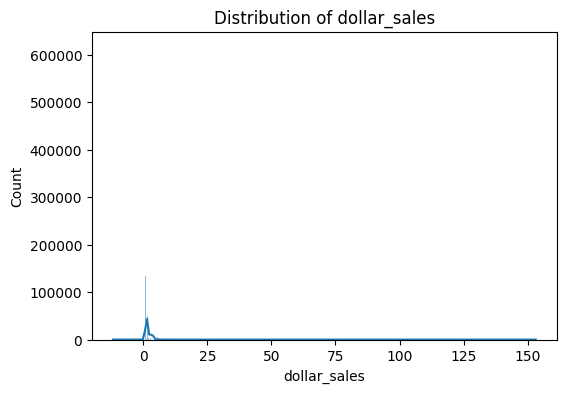


 Column: time_of_transaction
count    5.197681e+06
mean     1.543559e+03
std      3.850193e+02
min      0.000000e+00
25%      1.258000e+03
50%      1.602000e+03
75%      1.825000e+03
max      2.359000e+03
Name: time_of_transaction, dtype: float64


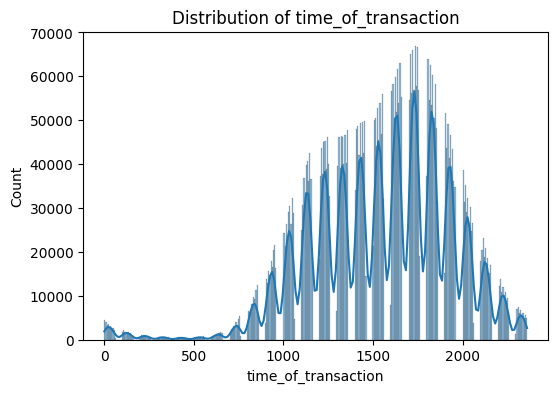

In [41]:
num_cols = ['dollar_sales', 'time_of_transaction']

os.makedirs("plots", exist_ok=True)

for col in num_cols:
    print(f"\n Column: {col}")

    print(df[col].describe())

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

    plt.savefig(f"plots/{col}_distribution.png", bbox_inches='tight')

    plt.show()

##  Distribution of Dollar Sales
- The distribution of dollar_sales is highly right-skewed, with most transactions having low values.
- A large number of purchases fall within a small price range, indicating frequent low-value transactions.
- There are a few high-value outliers, representing bulk or premium purchases.
- The sharp peak near lower values suggests common everyday buying behavior.
- This indicates that revenue is driven by volume of small transactions rather than large purchases.

##  Distribution of Time of Transaction
- The time_of_transaction shows a clear pattern of customer activity throughout the day.
- Transactions gradually increase and peak during midday to evening hours.
- The repeated peaks indicate cyclical shopping behavior (daily patterns).
- Lower activity is observed during early morning and late-night hours.
- This suggests optimal timing for targeted promotions and store operations planning.

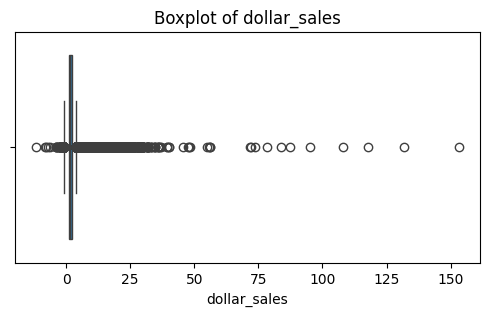

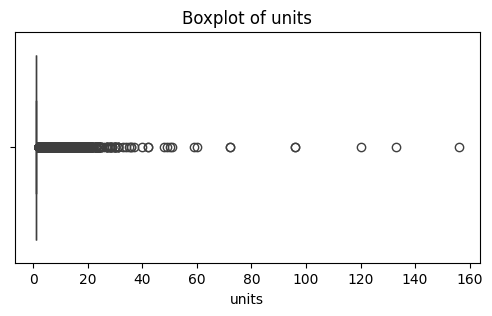

In [55]:
num_cols = ['dollar_sales', 'units']

os.makedirs("boxplots", exist_ok=True)

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

    plt.savefig(f"boxplots/{col}_boxplot.png", bbox_inches='tight')

    plt.show()

Outliers were retained because they represent genuine high-value transactions such as bulk purchases. Since market basket analysis is based on item co-occurrence rather than numerical magnitude, these outliers do not negatively impact the model.

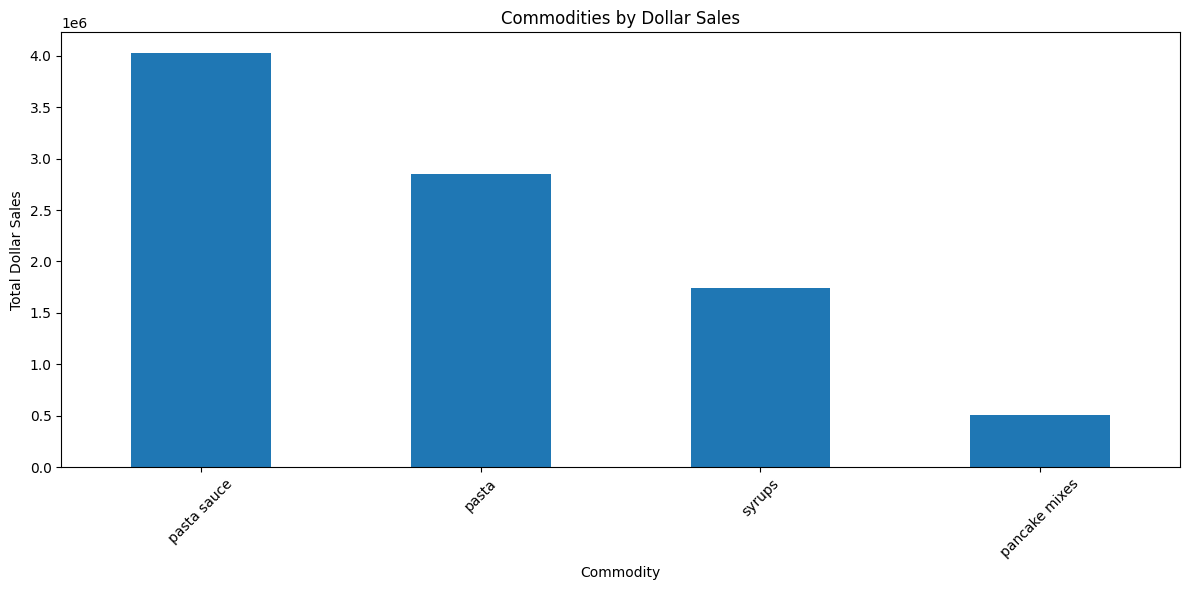

In [43]:
Top_sale_Commodities = df.groupby('commodity')['dollar_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
Top_sale_Commodities.plot(kind='bar')

plt.title('Commodities by Dollar Sales')
plt.xlabel('Commodity')
plt.ylabel('Total Dollar Sales')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('top_commodities.png', dpi=300, bbox_inches='tight')

plt.show()

## Commodities by Dollar Sales
- Pasta Sauce generates the highest total dollar sales, making it the top-performing category.
- Pasta follows as the second highest, indicating strong demand in this complementary category.
- Syrups show moderate sales, contributing steadily but less than pasta-related items.
- Pancake Mixes have the lowest sales, suggesting lower customer demand or purchase frequency.
- The strong performance of Pasta and Pasta Sauce highlights a clear opportunity for cross-promotions and bundling strategies.

<Figure size 1000x600 with 0 Axes>

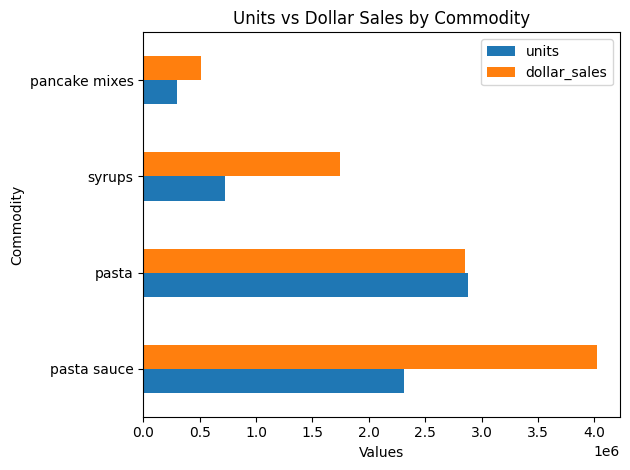

In [44]:
Revenue = df.groupby('commodity')[['units','dollar_sales']].sum()

Revenue = Revenue.sort_values('dollar_sales', ascending=False).head(10)

plt.figure(figsize=(10,6))
Revenue.plot(kind='barh')

plt.title('Units vs Dollar Sales by Commodity')
plt.xlabel('Values')
plt.ylabel('Commodity')

plt.tight_layout()

plt.savefig('units_vs_sales.png', dpi=300, bbox_inches='tight')

plt.show()

## Units vs Dollar Sales by Commodity
- Pasta has the highest units sold, indicating it is the most frequently purchased item.
- Pasta Sauce generates the highest dollar sales, despite fewer units than pasta, suggesting a higher price or value per unit.
- Syrups show moderate performance in both units and revenue, indicating balanced demand.
- Pancake Mixes have the lowest units and sales, reflecting weaker customer interest.
- The difference between units and revenue highlights opportunities for pricing strategies and product bundling, especially for pasta and pasta sauce.

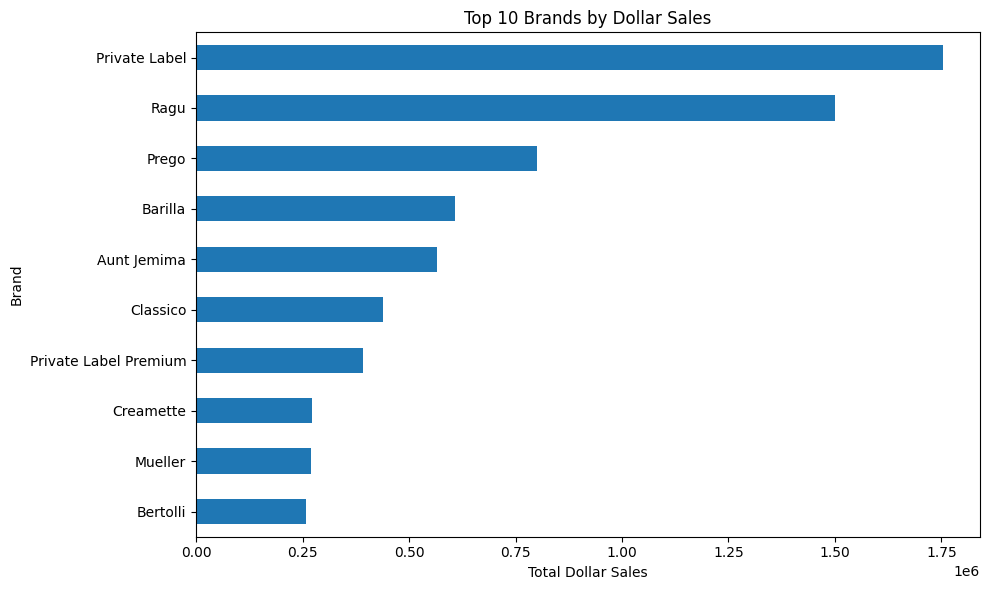

In [45]:
top10_brands = df.groupby('brand')['dollar_sales'] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head(10)

plt.figure(figsize=(10,6))
top10_brands.sort_values().plot(kind='barh')

plt.title('Top 10 Brands by Dollar Sales')
plt.xlabel('Total Dollar Sales')
plt.ylabel('Brand')

plt.tight_layout()

plt.savefig('top10_brands_sales.png', dpi=300, bbox_inches='tight')

plt.show()

## Top 10 Brands by Dollar Sales
- Private Label leads significantly in total dollar sales, indicating strong customer preference for store brands.
- Ragu and Prego are top-performing branded products, showing high demand in the sauce category.
- Mid-tier brands like Barilla and Aunt Jemima contribute moderately to overall revenue.
- Lower-ranked brands such as Mueller and Bertolli have comparatively smaller sales volumes.
- The dominance of private labels suggests opportunities for higher margins and strategic promotion of store-owned brands.

## 5. Feature Engineering

/tmp/ipykernel_9268/3841239424.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['unique_categories'] = df.groupby('basket')['commodity'].transform('nunique')


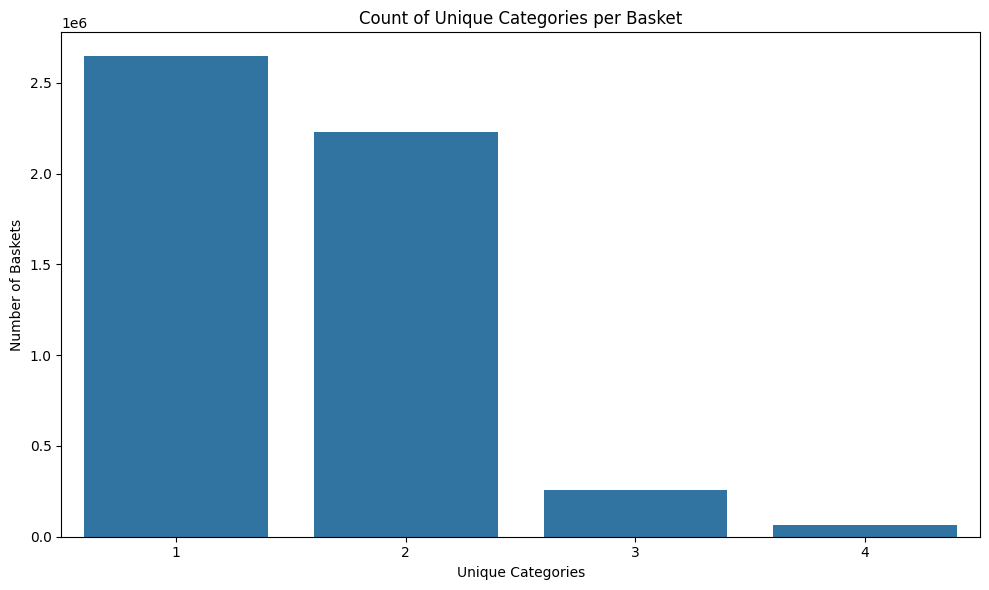

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

df['unique_categories'] = df.groupby('basket')['commodity'].transform('nunique')

plt.figure(figsize=(10,6))
sns.countplot(
    x='unique_categories',
    data=df,
    order=df['unique_categories'].value_counts().index
)

plt.title('Count of Unique Categories per Basket')
plt.xlabel('Unique Categories')
plt.ylabel('Number of Baskets')

plt.tight_layout()

plt.savefig('unique_categories_per_basket.png', dpi=300, bbox_inches='tight')

plt.show()

## Count of Unique Categories per Basket
- Most baskets contain 1 to 2 unique categories, indicating focused purchasing behavior.
- A significant drop is observed for baskets with 3 or more categories, showing fewer diversified purchases.
- This suggests customers typically shop for specific needs rather than broad variety.
- Limited category diversity highlights strong potential for cross-category recommendations.
- Encouraging multi-category purchases can help increase the average basket value.

In [48]:
df['pasta_flag'] = (df['commodity'] == 'PASTA').astype(int)
df['sauce_flag'] = (df['commodity'] == 'PASTA SAUCE').astype(int)

basket_flags = df.groupby('basket')[['pasta_flag','sauce_flag']].sum()

basket_flags['pasta_sauce_combo'] = (
    (basket_flags['pasta_flag'] > 0) &
    (basket_flags['sauce_flag'] > 0)
).astype(int)

/tmp/ipykernel_9268/179315242.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basket_flags = df.groupby('basket')[['pasta_flag','sauce_flag']].sum()


## Identifying Pasta & Sauce Combinations
- Created binary flags to identify whether a basket contains Pasta or Pasta Sauce.
- Aggregated data at the basket level to track product presence per transaction.
- Generated a pasta_sauce_combo flag to identify baskets containing both items.
- This helps isolate complementary product purchases for deeper analysis.
- The feature is essential for detecting cross-selling and bundling opportunities.

/tmp/ipykernel_9268/2532972806.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['customer_total_spend'] = df.groupby('household')['dollar_sales'].transform('sum')


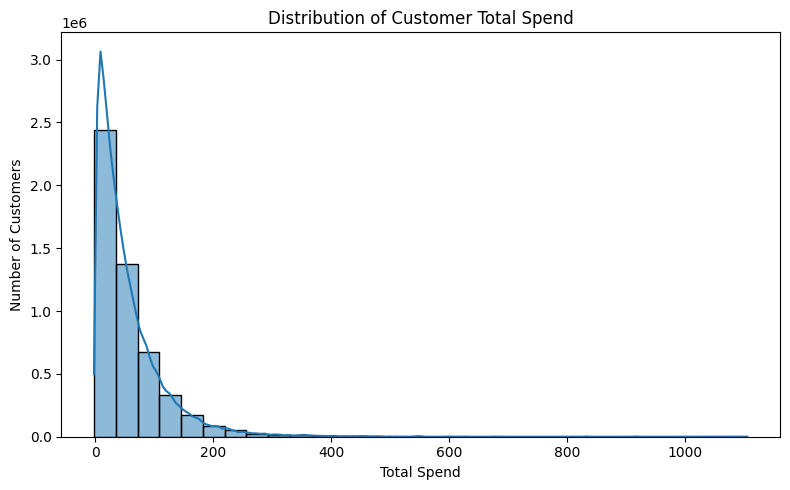

In [49]:
df['customer_total_spend'] = df.groupby('household')['dollar_sales'].transform('sum')

plt.figure(figsize=(8,5))
sns.histplot(df['customer_total_spend'], bins=30, kde=True)

plt.title('Distribution of Customer Total Spend')
plt.xlabel('Total Spend')
plt.ylabel('Number of Customers')

plt.tight_layout()

plt.savefig('customer_total_spend_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

## Distribution of Customer Total Spend
- The distribution of customer total spend is highly right-skewed, with most customers spending relatively low amounts.
- A small number of customers contribute to very high spending, indicating the presence of high-value customers.
- The majority of customers fall within a low to moderate spending range.
- This highlights an opportunity to identify and target high-value customer segments.
- Businesses can use this insight for personalized marketing and loyalty programs to increase retention and revenue.

/tmp/ipykernel_9268/2823821490.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['product_popularity'] = df.groupby('upc')['units'].transform('sum')


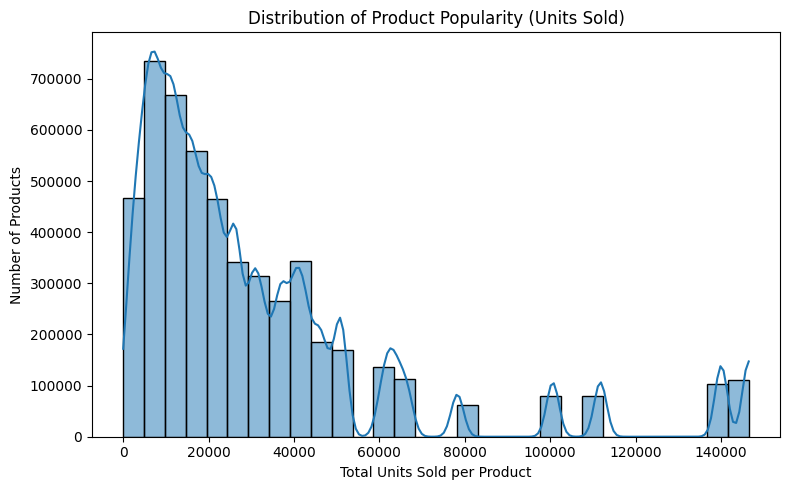

In [50]:
df['product_popularity'] = df.groupby('upc')['units'].transform('sum')

plt.figure(figsize=(8,5))
sns.histplot(df['product_popularity'], bins=30, kde=True)

plt.title('Distribution of Product Popularity (Units Sold)')
plt.xlabel('Total Units Sold per Product')
plt.ylabel('Number of Products')

plt.tight_layout()

plt.savefig('product_popularity_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

## Distribution of Product Popularity (Units Sold)
- The distribution is right-skewed, with most products having low to moderate sales volumes.
- A small number of products show very high units sold, indicating best-selling or popular items.
- The majority of products fall into the long-tail category, contributing less individually.
- This highlights the classic Pareto principle (few products drive most sales).
- Businesses can focus on top-performing products while optimizing or promoting low-performing ones.

In [51]:
df['price_per_unit'] = df['dollar_sales'] / df['units']

## Price per Unit Calculation
- Calculated price_per_unit by dividing total sales (dollar_sales) by number of units sold.
- This metric helps understand the average selling price of each product.
- Useful for analyzing pricing strategies and product value differences.

In [52]:
df['day_sales'] = df.groupby('day')['dollar_sales'].transform('sum')

## Daily Sales Aggregation
- Calculated total day_sales by aggregating dollar_sales for each day.
- This helps analyze daily revenue patterns and trends over time.
- Useful for identifying peak sales days and planning promotions.

In [53]:
df

,upc,dollar_sales,units,time_of_transaction,geography,week,household,store,basket,day,...,commodity,brand,product_size,unique_categories,pasta_flag,sauce_flag,customer_total_spend,product_popularity,price_per_unit,day_sales
0,7680850106,0.80,1,1100,2,1,125434,244,1,1,...,pasta,Barilla,16 OZ,2,0,0,58.96,40057,0.80,13710.28
1,3620000470,3.59,1,1100,2,1,125434,244,1,1,...,pasta sauce,Bertolli,24 OZ,2,0,0,58.96,13539,3.59,13710.28
2,1800028064,2.25,1,1137,2,1,108320,244,2,1,...,pancake mixes,Hungry Jack,,1,0,0,107.60,22569,2.25,13710.28
3,9999985067,0.85,1,1148,2,1,162016,244,3,1,...,pasta,Private Label,16 OZ,1,0,0,295.21,45847,0.85,13710.28
4,9999985131,2.19,1,1323,2,1,89437,244,4,1,...,pasta,Private Label Premium,16 OZ,2,0,0,68.50,1617,2.19,13710.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5197676,9999985001,0.39,1,2354,1,104,435465,199,3316346,728,...,pasta,Private Label,N 7 OZ,2,0,0,5.71,60403,0.39,15592.37
5197677,9999966720,1.05,1,2354,1,104,435465,199,3316346,728,...,pasta sauce,Private Label,26 OZ,2,0,0,5.71,13942,1.05,15592.37
5197678,9999985027,0.99,1,2311,1,104,352690,218,3316347,728,...,pasta,Private Label,16 OZ,1,0,0,4.68,50664,0.99,15592.37
5197679,3620000300,1.53,1,2245,1,104,55530,93,3316348,728,...,pasta sauce,Ragu,26 OZ,1,0,0,73.77,62756,1.53,15592.37


In [ ]:
df.to_csv("raw.csv")

- Built a custom transformer to standardize product sizes by converting all values into ounces.
- Handled inconsistent formats (e.g., LB, OZ, invalid tags) and removed noisy entries.
- Created a clean feature product_size_clean for consistent analysis.
- Applied a second transformer to handle missing values using median imputation.
- This ensures reliable and uniform data for downstream modeling and analysis.

In [ ]:
!python main.py

/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
                   antecedents    consequents   support  confidence      lift
13         SYRUPS, PASTA SAUCE  PANCAKE MIXES  0.006173    0.216998  2.726870
4                PASTA, SYRUPS  PANCAKE MIXES  0.006874    0.207782  2.611061
12  PANCAKE MIXES, PASTA SAUCE         SYRUPS  0.006173    0.469714  2.364592
5         PANCAKE MIXES, PASTA         SYRUPS  0.006874    0.456068  2.295897
3                       SYRUPS  PANCAKE MIXES  0.032470    0.163458  2.054070
2                PANCAKE MIXES         SYRUPS  0.032470    0.408030  2.054070
8         PANCAKE MIXES, PASTA    PASTA SAUCE  0.008321    0.552055  1.185795
16               PASTA, SYRUPS    PASTA SAUCE  0.017168    0.518931  1.114646
9   PANCAKE MI

## Association Rules & Cross-Promotional Insights
- Strong associations were identified between Syrups and Pancake Mixes, with high lift (>2) indicating a strong co-purchase relationship.
- Multi-item combinations (e.g., Pasta + Syrups → Pancake Mixes) show meaningful patterns, suggesting bundle opportunities across categories.
- However, Pasta → Pasta Sauce shows moderate support but lift < 1, indicating weaker-than-expected association despite being complementary.
- This suggests that customers do not always buy pasta and sauce together, highlighting a missed cross-selling opportunity.
- Businesses can leverage strong rules for bundling (Syrups + Pancake Mixes) and improve weaker links (Pasta + Sauce) through targeted promotions and placement strategies.